In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\eda_project\notebook\visualisation3")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8789,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0
8790,s8804,TV Show,Zombie Dumb,Unknown,Not Available,United States,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0
8791,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88.0
8792,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88.0


In [7]:
#Time-Based Feature Extraction
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day
year_counts = df['year_added'].value_counts().sort_index()



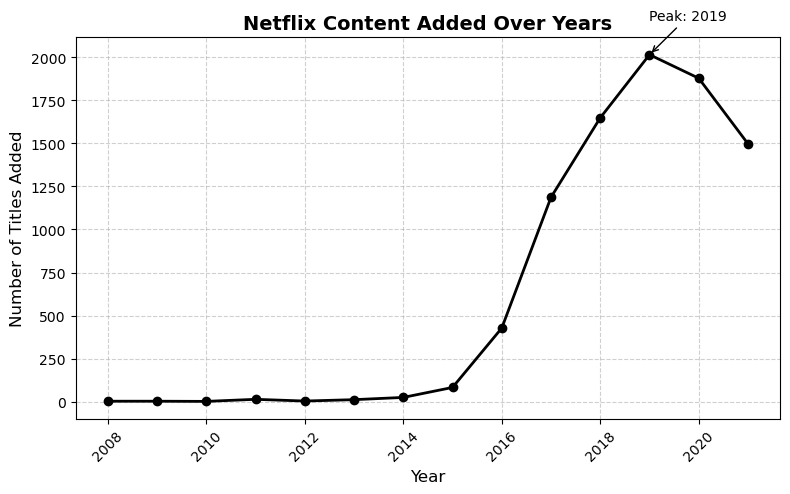

In [13]:
#Time Trend Analysis
#Content added over years
plt.figure(figsize=(8,5))

plt.plot(year_counts.index, year_counts.values,
         color='black', marker='o', linewidth=2)

plt.title("Netflix Content Added Over Years",
          fontsize=14, fontweight='bold')

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles Added", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
max_year = year_counts.idxmax()
max_value = year_counts.max()

plt.annotate(f'Peak: {max_year}',
             xy=(max_year, max_value),
             xytext=(max_year, max_value+200),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10)


plt.savefig("netflix_trend_bw.png", bbox_inches='tight')
plt.show()


- Content addition remained very low until around 2015.
- There is a sharp increase in content additions from 2016 to 2018, indicating rapid growth.
- After peaking around 2019, content additions show a declining trend in the following years.



##  Recommendations

- Focus on producing and adding more recent content, as most available content is from recent years.

- Continue strengthening the movie library since movies dominate the platform.

- Increase content in popular genres such as International Movies, Drama, and Comedy.

- Invest more in mature content (TV-MA, TV-14) as it is more common in recent releases.

- Maintain a balance between short and long duration content to suit different audience preferences.

- Expand content from multiple countries to improve global reach and diversity.

- Ensure consistent content addition over time, as growth peaked and then showed a decline.

-  Focus on producing more TV Shows, as they are fewer compared to movies but can improve user retention.

- Enhance recommendation systems using genre, rating, and viewing patterns for better personalization.

- Increase investment in quality content to differentiate from competitors.



## Feature Engineering

In [5]:
# 1
df['is_movie'] = df['type'].apply(lambda x: 1 if x=='Movie' else 0)
# 2
df['content_age'] = 2026 - df['release_year']
# 3
df['month_name'] = df['date_added'].dt.month_name()
# 4
df['is_recent'] = df['release_year'].apply(lambda x: 1 if x > 2015 else 0)
# 5
df['duration_category'] = df['duration_num'].apply(lambda x: 'Short' if x<60 else 'Long')


## Statistical Tests
## Chi-Square Test


In [6]:
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['type'], df['rating'])
chi2, p, dof, expected = chi2_contingency(contingency)
print("Chi-square value:", chi2)
print("P-value:", p)

Chi-square value: 1044.6688903758443
P-value: 4.4373048214820157e-215


In [7]:
#Interpretation:
if p < 0.05:
    print("Significant relationship")
else:
    print("No significant relationship")


Significant relationship


## CHI_SQUARE INSIGHT
- The Chi-square test checks the relationship between content type and rating.
- A p-value less than 0.05 indicates a significant relationship between type and rating.
- This shows Movies and TV Shows have different rating distributions.
- The Chi-square test indicates a statistically significant relationship between content type and rating. This supports the visual observation that Movies and TV Shows have different rating distributions, indicating that content type influences the distribution of ratings.



## T-Test



In [8]:
from scipy import stats
movies = df[df['type'] == 'Movie']['release_year']
tvshows = df[df['type'] == 'TV Show']['release_year']
t_stat, p_value = stats.ttest_ind(movies.dropna(), tvshows.dropna())
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -17.411066308054494
P-value: 8.8983972321694e-67


## T-Test Insight

- The T-test was performed to compare the release years of Movies and TV Shows.
- The p-value is extremely small , which is much less than 0.05. This indicates that there is a statistically significant difference between the release years of Movies and TV Shows.
- This means Movies and TV Shows on Netflix were released in different time periods on average. It suggests that TV Show is more concentrated in certain release years compared to the other.
-The t-test results show a statistically significant difference in the mean release year between Movies and TV Shows (p < 0.05). Therefore, the null hypothesis is rejected, and the alternative hypothesis is accepted. This confirms that TV Shows tend to be more recent than Movies, supporting the pattern observed in the boxplot.


## ANOVA 

In [9]:
from scipy.stats import f_oneway
groups =[group['release_year'].values for name, group in df.groupby('rating')]
f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 75.92626652182071
P-value: 9.712335189630549e-192


In [10]:
 ## Interpretation
if p_value < 0.05:
    print("Significant difference between groups")
else:
    print("No significant difference")


Significant difference between groups


### ANOVA Insight

- The ANOVA test compares release years across different rating categories.
- If the p-value is less than 0.05, it indicates a significant difference between rating groups.
- This helps understand whether different rating categories are associated with different release periods.
- The boxplot indicates that most rating categories are concentrated in recent years, with similar median release years across several groups such as TV-14, TV-PG, and TV-Y7. While higher maturity ratings like TV-MA show slight variation, certain ratings such as PG-13 and R exhibit a wider spread in release years. A one-way ANOVA test was conducted to examine whether these differences are statistically significant. The results indicate a significant difference in mean release years across rating categories (p < 0.05), leading to the rejection of the null hypothesis. This suggests that at least one rating group differs in mean release year, although the overall variation across groups is relatively moderate.”

In [37]:
df.to_csv(r"C:\Users\HP\OneDrive\Desktop\final4", index=False)


## Time Analysis Summary
Content addition on Netflix has increased rapidly over the years, especially after 2015.
There is a sharp increase in content additions from 2016 to 2018, indicating rapid growth.
After peaking around 2019, content additions show a declining trend in the following years.


## Feature Engineering Summary
New features such as content age, month added, and duration category were created to enhance analysis.


## Statistical Analysis Summary
Chi-square, T-test, and ANOVA were performed to analyze relationships and differences in the dataset. The results indicate significant patterns between variables such as type, rating, and numerical features.


## Final Insights

1. Movies dominate Netflix content compared to TV Shows.
2. Most content on Netflix is rated TV-MA and TV-14.
3. The majority of content was released after 2010.
4. Netflix content addition increased significantly after 2015.
5. USA is the leading country producing Netflix content.
6. Drama and International genres are the most common.
7. TV Shows tend to be more recent than Movies.
8. A significant relationship exists between content type and rating (Chi-square test).
9. Duration differs between Movies and TV Shows (T-test result).
10. Release year varies across rating categories (ANOVA result).


## Segment Findings

- Movies are more frequent but TV Shows are growing faster in recent years.
- Certain ratings (TV-MA) are dominant in specific genres.
- Content from specific countries (like USA) dominates the platform.


## Data Quality Issues

- Missing values in director, cast, country,rating and duration columns
- Mixed format in duration column (minutes and seasons)
- Some inconsistencies in categorical data
- there have inappropriate data on rating 
